# 📚 Text Category Classifier — XLM-RoBERTa
## Persistent saved model + optional retraining


Install Dependencies

In [1]:
!pip install transformers datasets scikit-learn seaborn matplotlib torch --quiet
print("Dependencies installed")

Dependencies installed


Imports & GPU Check

In [2]:
import json
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import Counter

import torch
from torch.utils.data import Dataset
from transformers import (
    XLMRobertaTokenizerFast,
    XLMRobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Go to Runtime → Change runtime type → GPU")


Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


Configurations


In [3]:
# ─── USER CONFIGURATION ───────────────────────────────────────────────────────

DATA_PATH         = "data.json"          # Used only when training/retraining
MODEL_NAME        = "xlm-roberta-base"   # Or "xlm-roberta-large" for better accuracy
OUTPUT_DIR        = "./xlmr_classifier"  # Temporary trainer checkpoint/output dir

# Save to Google Drive so the model survives Colab runtime resets.
# Change this path if you want a different saved model location.
USE_GOOGLE_DRIVE  = True
DRIVE_MODEL_DIR   = "/content/drive/MyDrive/xlmr_severity_context_classifier_saved_model"
LOCAL_MODEL_DIR   = "./saved_model"
SAVED_MODEL_DIR   = DRIVE_MODEL_DIR if USE_GOOGLE_DRIVE else LOCAL_MODEL_DIR

# IMPORTANT:
# False = load the existing saved model if it exists, and SKIP training.
# True  = train again from the beginning and replace the saved model.
FORCE_RETRAIN     = True

# Training hyperparameters
MAX_LENGTH        = 256     # Max token length (increase if texts are long)
BATCH_SIZE        = 16      # Reduce to 8 if you get OOM errors
EPOCHS            = 5
LEARNING_RATE     = 2e-5
WEIGHT_DECAY      = 0.01
WARMUP_RATIO      = 0.1
TEST_SIZE         = 0.15    # 15% test split
VAL_SIZE          = 0.15    # 15% validation split
SEED              = 42

# ──────────────────────────────────────────────────────────────────────────────

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

def is_saved_model_available(model_dir):
    """Return True when a Hugging Face saved model directory looks complete."""
    model_dir = Path(model_dir)
    required_files = [
        "config.json",
        "label_map.json",
    ]
    has_weights = (model_dir / "model.safetensors").exists() or (model_dir / "pytorch_model.bin").exists()
    has_tokenizer = (model_dir / "tokenizer.json").exists() or (model_dir / "sentencepiece.bpe.model").exists()
    return model_dir.exists() and has_weights and has_tokenizer and all((model_dir / f).exists() for f in required_files)

MODEL_EXISTS = is_saved_model_available(SAVED_MODEL_DIR)
SHOULD_TRAIN = FORCE_RETRAIN or not MODEL_EXISTS

print("Configuration set")
print(f"Saved model directory: {SAVED_MODEL_DIR}")
print(f"Existing saved model found: {MODEL_EXISTS}")
print(f"FORCE_RETRAIN: {FORCE_RETRAIN}")
print(f"This run will: {'TRAIN from scratch and replace saved model' if SHOULD_TRAIN else 'LOAD saved model and skip training'}")


Mounted at /content/drive
Configuration set
Saved model directory: /content/drive/MyDrive/xlmr_severity_context_classifier_saved_model
Existing saved model found: True
FORCE_RETRAIN: True
This run will: TRAIN from scratch and replace saved model


Training Data Upload

In [4]:
from google.colab import files

if SHOULD_TRAIN:
    print("📂 Training/retraining needs a JSON training file.")
    print("Please upload your JSON training file...")
    uploaded = files.upload()

    # Use whichever file was uploaded
    uploaded_filename = list(uploaded.keys())[0]
    DATA_PATH = uploaded_filename
    print(f"Uploaded: {DATA_PATH}")
else:
    print("Saved model exists and FORCE_RETRAIN=False.")
    print("Skipping training data upload because the notebook will load the saved model.")


📂 Training/retraining needs a JSON training file.
Please upload your JSON training file...


Saving data.json to data.json
Uploaded: data.json


Data Exploration

In [5]:
def load_json_data(path):
    """Load JSON or JSONL training data."""
    with open(path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    # Try JSON array first, then JSONL
    try:
        data = json.loads(content)
        if isinstance(data, dict):  # Single object — wrap in list
            data = [data]
    except json.JSONDecodeError:
        data = [json.loads(line) for line in content.splitlines() if line.strip()]

    df = pd.DataFrame(data)
    assert "text" in df.columns and "category" in df.columns, \
        "JSON must have 'text' and 'category' fields"

    # Clean up
    df["text"] = df["text"].astype(str).str.strip()
    df["category"] = df["category"].astype(str).str.strip().str.lower()
    df = df.dropna(subset=["text", "category"])
    df = df[df["text"] != ""]
    return df


if SHOULD_TRAIN:
    df = load_json_data(DATA_PATH)
    print(f" Loaded {len(df):,} samples")
    print(f"   Categories: {sorted(df['category'].unique())}")
    print(f"\n   Class distribution:")
    print(df["category"].value_counts().to_string())
    print(f"\n   Avg text length: {df['text'].str.len().mean():.0f} chars")
    display(df.head(3))
else:
    df = None
    print("Skipping data exploration because saved model is being loaded.")


 Loaded 1,991 samples
   Categories: ['info', 'noninfo']

   Class distribution:
category
noninfo    1000
info        991

   Avg text length: 129 chars


,text,category
0,"අමල් පෙරේරාගේ ඉතිරිකිරීමේ ගිණුමෙන් රුපියල් 50,...",noninfo
1,"Amal Pererage savings account eken Rs. 50,000k...",noninfo
2,2024 මාර්තු 15 වන දින පස්වරු 2:15ට සම්පත් බැංක...,noninfo


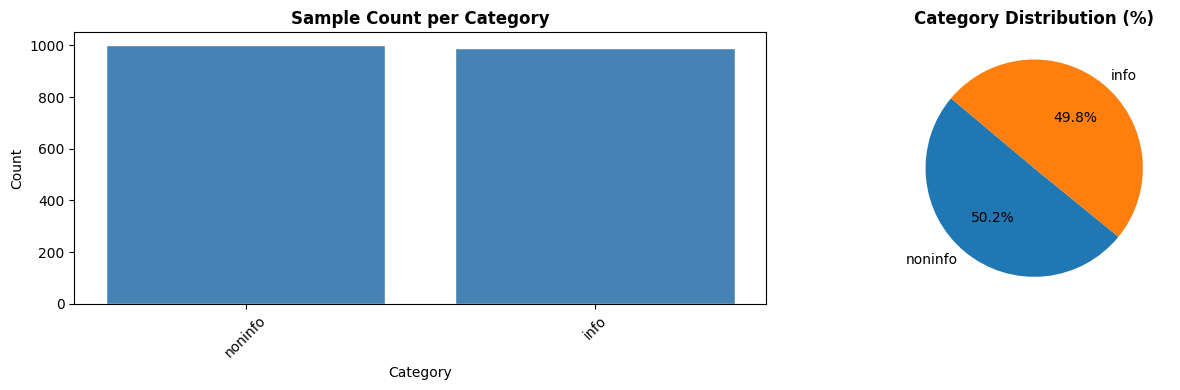

In [6]:
if SHOULD_TRAIN:
    # Visualize class distribution
    counts = df["category"].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Bar chart
    axes[0].bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    axes[0].set_title("Sample Count per Category", fontweight="bold")
    axes[0].set_xlabel("Category")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)

    # Pie chart
    axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=140)
    axes[1].set_title("Category Distribution (%)", fontweight="bold")

    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150)
    plt.show()

    # Warn about class imbalance
    min_count, max_count = counts.min(), counts.max()
    if max_count / min_count > 3:
        print(f"Class imbalance detected (ratio {max_count/min_count:.1f}x). "
              "Consider oversampling or class weights.")
else:
    print("⏭Skipping class distribution chart.")


Label Encoding & Data Split

In [7]:
if SHOULD_TRAIN:
    # Build label mappings
    categories = sorted(df["category"].unique())
    label2id   = {cat: i for i, cat in enumerate(categories)}
    id2label   = {i: cat for cat, i in label2id.items()}
    num_labels = len(categories)

    df["label"] = df["category"].map(label2id)

    print(f"  {num_labels} categories:")
    for cat, idx in label2id.items():
        print(f"   [{idx}] {cat}")

    # Save label map locally first; final copy is saved into SAVED_MODEL_DIR after training.
    with open("label_map.json", "w", encoding="utf-8") as f:
        json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)
    print("\nlabel_map.json saved locally")
else:
    with open(Path(SAVED_MODEL_DIR) / "label_map.json", encoding="utf-8") as f:
        maps = json.load(f)

    label2id = maps["label2id"]
    id2label = {int(k): v for k, v in maps["id2label"].items()}
    categories = [id2label[i] for i in sorted(id2label)]
    num_labels = len(categories)

    print(f"Loaded label map from saved model: {num_labels} categories")
    for idx, cat in id2label.items():
        print(f"   [{idx}] {cat}")


  2 categories:
   [0] info
   [1] noninfo

label_map.json saved locally


In [8]:
if SHOULD_TRAIN:
    # Stratified train / val / test split
    train_df, temp_df = train_test_split(
        df, test_size=(TEST_SIZE + VAL_SIZE), stratify=df["label"], random_state=SEED
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
        stratify=temp_df["label"],
        random_state=SEED,
    )

    print(f"Split sizes:")
    print(f"   Train : {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"   Val   : {len(val_df):,}   ({len(val_df)/len(df)*100:.1f}%)")
    print(f"   Test  : {len(test_df):,}   ({len(test_df)/len(df)*100:.1f}%)")
else:
    train_df = val_df = test_df = None
    print("Skipping data split because saved model is being loaded.")


Split sizes:
   Train : 1,393 (70.0%)
   Val   : 299   (15.0%)
   Test  : 299   (15.0%)


Tokenization

In [9]:
tokenizer_source = MODEL_NAME if SHOULD_TRAIN else SAVED_MODEL_DIR
print(f"Loading tokenizer from: {tokenizer_source}")
tokenizer = XLMRobertaTokenizerFast.from_pretrained(tokenizer_source)

if SHOULD_TRAIN:
    # Analyze token length distribution to validate MAX_LENGTH
    sample_lengths = [
        len(tokenizer.encode(t, truncation=False))
        for t in df["text"].sample(min(500, len(df)), random_state=SEED)
    ]
    p95 = int(np.percentile(sample_lengths, 95))
    print(f"\nToken length stats (sampled):")
    print(f"   Median : {int(np.median(sample_lengths))}")
    print(f"   P95    : {p95}")
    print(f"   Max    : {max(sample_lengths)}")
    if p95 > MAX_LENGTH:
        print(f"P95 ({p95}) > MAX_LENGTH ({MAX_LENGTH}). "
              "Consider increasing MAX_LENGTH.")
    else:
        print(f"MAX_LENGTH={MAX_LENGTH} covers 95%+ of samples")
else:
    print("Tokenizer loaded from saved model.")


Loading tokenizer from: xlm-roberta-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Token length stats (sampled):
   Median : 38
   P95    : 66
   Max    : 82
MAX_LENGTH=256 covers 95%+ of samples


In [10]:
class TextCategoryDataset(Dataset):
    """PyTorch Dataset for tokenized text classification."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }


if SHOULD_TRAIN:
    print("Tokenizing datasets...")
    train_dataset = TextCategoryDataset(train_df["text"], train_df["label"], tokenizer, MAX_LENGTH)
    val_dataset   = TextCategoryDataset(val_df["text"],   val_df["label"],   tokenizer, MAX_LENGTH)
    test_dataset  = TextCategoryDataset(test_df["text"],  test_df["label"],  tokenizer, MAX_LENGTH)

    print(f"Tokenized: {len(train_dataset)} train | {len(val_dataset)} val | {len(test_dataset)} test")
else:
    train_dataset = val_dataset = test_dataset = None
    print("Skipping dataset tokenization because saved model is being loaded.")


Tokenizing datasets...
Tokenized: 1393 train | 299 val | 299 test


Model Setup

In [11]:
model_source = MODEL_NAME if SHOULD_TRAIN else SAVED_MODEL_DIR
print(f"Loading model from: {model_source}")

if SHOULD_TRAIN:
    # Start from the base pretrained model when retraining.
    model = XLMRobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    )
else:
    # Load your previously trained model.
    model = XLMRobertaForSequenceClassification.from_pretrained(SAVED_MODEL_DIR)

model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n Model size:")
print(f"   Total params    : {total_params/1e6:.1f}M")
print(f"   Trainable params: {trainable_params/1e6:.1f}M")
print(f"   Output classes  : {num_labels}")


Loading model from: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Model size:
   Total params    : 278.0M
   Trainable params: 278.0M
   Output classes  : 2


Model Training

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }

In [13]:
if SHOULD_TRAIN:
    # Handle renamed arg: evaluation_strategy → eval_strategy (transformers >= 4.46)
    import transformers
    _tver = tuple(int(x) for x in transformers.__version__.split(".")[:2])
    _eval_kwarg = "eval_strategy" if _tver >= (4, 46) else "evaluation_strategy"

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        **{_eval_kwarg: "epoch"},
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        logging_steps=10,
        fp16=torch.cuda.is_available(),    # Mixed precision on GPU
        seed=SEED,
        report_to="none",                  # Disable WandB
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    print("Starting training from the base model...")
    train_result = trainer.train()
    print("\nTraining complete!")
    print(f"   Runtime   : {train_result.metrics['train_runtime']:.0f}s")
    print(f"   Samples/s : {train_result.metrics['train_samples_per_second']:.1f}")
else:
    trainer = None
    print("Saved model loaded. Training skipped.")
    print("To train from scratch and replace the saved model, set FORCE_RETRAIN=True and run the notebook again.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training from the base model...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.314511,0.171655,0.939799,0.939766,0.939771
2,0.175151,0.192523,0.946488,0.946416,0.946422
3,0.099851,0.127934,0.976589,0.976584,0.976583
4,0.041922,0.116837,0.976589,0.976588,0.976588
5,0.060033,0.104176,0.976589,0.976588,0.976588


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete!
   Runtime   : 515s
   Samples/s : 13.5


Model Evaluation

In [14]:
if SHOULD_TRAIN:
    # Evaluate on test set
    print("Evaluating on test set...")
    test_output = trainer.predict(test_dataset)
    preds  = np.argmax(test_output.predictions, axis=-1)
    labels = test_output.label_ids

    acc      = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro",    zero_division=0)
    f1_wt    = f1_score(labels, preds, average="weighted", zero_division=0)

    print(f"\n{'='*45}")
    print(f"  Test Accuracy  : {acc*100:.2f}%")
    print(f"  F1 Macro       : {f1_macro*100:.2f}%")
    print(f"  F1 Weighted    : {f1_wt*100:.2f}%")
    print(f"{'='*45}\n")
    print(classification_report(labels, preds, target_names=categories, zero_division=0))
else:
    preds = labels = None
    print("Skipping test evaluation because no test data was uploaded when loading a saved model.")


Evaluating on test set...



  Test Accuracy  : 97.66%
  F1 Macro       : 97.66%
  F1 Weighted    : 97.66%

              precision    recall  f1-score   support

        info       0.99      0.97      0.98       149
     noninfo       0.97      0.99      0.98       150

    accuracy                           0.98       299
   macro avg       0.98      0.98      0.98       299
weighted avg       0.98      0.98      0.98       299



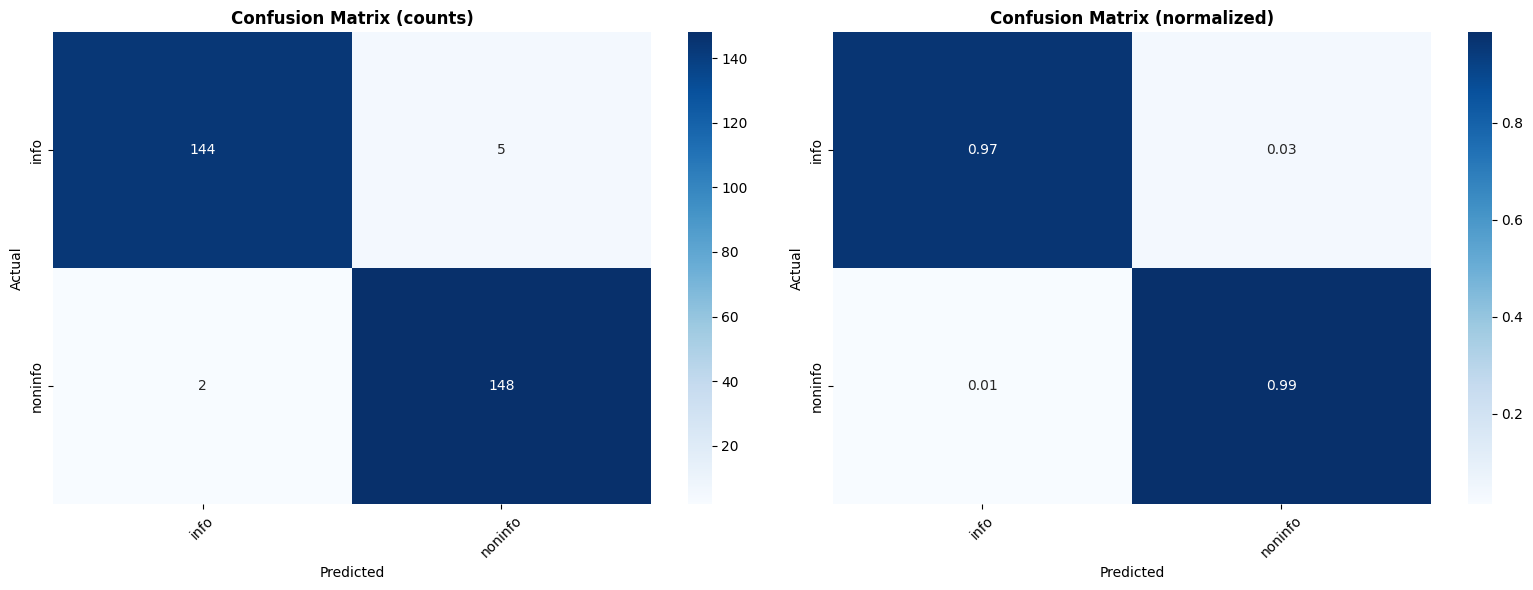

In [15]:
if SHOULD_TRAIN:
    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, data, fmt, title in [
        (axes[0], cm,      "d",    "Confusion Matrix (counts)"),
        (axes[1], cm_norm, ".2f",  "Confusion Matrix (normalized)"),
    ]:
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=categories, yticklabels=categories, ax=ax,
        )
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
else:
    print("Skipping confusion matrix because evaluation was skipped.")


Save Model

In [16]:
if SHOULD_TRAIN:
    temp_save_dir = Path("./latest_retrained_model_temp")

    # Clean previous temporary save if it exists
    if temp_save_dir.exists():
        shutil.rmtree(temp_save_dir)

    # Save the newly trained model to a temporary directory first
    trainer.save_model(str(temp_save_dir))
    tokenizer.save_pretrained(str(temp_save_dir))

    # Save label map inside the model dir too
    with open(temp_save_dir / "label_map.json", "w", encoding="utf-8") as f:
        json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)

    # Save small training metadata file
    training_info = {
        "saved_at": datetime.now().isoformat(timespec="seconds"),
        "base_model": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "num_labels": num_labels,
        "categories": categories,
        "force_retrain_was": FORCE_RETRAIN,
    }
    with open(temp_save_dir / "training_info.json", "w", encoding="utf-8") as f:
        json.dump(training_info, f, ensure_ascii=False, indent=2)

    # Replace the latest saved model with this newly trained model
    saved_path = Path(SAVED_MODEL_DIR)
    if saved_path.exists():
        shutil.rmtree(saved_path)
    shutil.move(str(temp_save_dir), str(saved_path))

    print(f"New model saved and replaced latest saved model at: {SAVED_MODEL_DIR}")
    print("   Files:")
    for fp in sorted(Path(SAVED_MODEL_DIR).iterdir()):
        size = fp.stat().st_size / 1e6
        print(f"   {fp.name:<35} {size:.1f} MB")
else:
    print(f"Using existing saved model at: {SAVED_MODEL_DIR}")
    print("No files were replaced because FORCE_RETRAIN=False.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

New model saved and replaced latest saved model at: /content/drive/MyDrive/xlmr_severity_context_classifier_saved_model
   Files:
   config.json                         0.0 MB
   label_map.json                      0.0 MB
   model.safetensors                   1112.2 MB
   tokenizer.json                      16.8 MB
   tokenizer_config.json               0.0 MB
   training_args.bin                   0.0 MB
   training_info.json                  0.0 MB


Checking new inputs


In [24]:
import re
import math

def get_label_name(id2label, idx):
    """Works with either int keys or JSON-loaded string keys."""
    return id2label.get(idx, id2label.get(str(idx), str(idx)))


def predict(texts, model, tokenizer, id2label, max_length=MAX_LENGTH, top_k=3):
    """Predict category with confidence scores for a list of texts."""
    if isinstance(texts, str):
        texts = [texts]

    model.eval()
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        logits = model(**encodings).logits

    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    results = []
    for prob_row in probs:
        top_indices = prob_row.argsort()[::-1][:top_k]
        results.append([
            {"category": get_label_name(id2label, int(i)), "confidence": float(prob_row[i])}
            for i in top_indices
        ])
    return results


def strip_tags_and_count(text):
    """Remove entity tags and count occurrences by tag name."""
    counts = {}
    pattern = re.compile(r"<(?P<tag>[^>/]+)>(?P<val>.*?)</\1>", re.DOTALL)
    def _repl(match):
        tag = match.group("tag").strip()
        counts[tag] = counts.get(tag, 0) + 1
        return match.group("val")
    cleaned = pattern.sub(_repl, text)
    return cleaned, counts


ENTITY_SCORES = {
    "Date":0.6,
    "Name": 0.6,
    "PhoneNo" : 0.8,
    "BankAccNo": 0.9,
    "Location": 0.6,
    "Organization": 0.5,
}

CONTEXT_SCORES = {
    "INFO": 0.3,
    "NONINFO":0.9
}

# score calculation --------------------------------------------------------------
# Entity_Score = Base_Score * ( 1 + α.log(1+ Count) )
# Total_Score = 1 - exp(- sum(Entity_Score))

def compute_final_score(tag_counts, category):
    α = 0.3
    entity_score = sum(ENTITY_SCORES.get(tag, 0) * (1 + α*math.log(1+count)) for tag, count in tag_counts.items())
    context_score = CONTEXT_SCORES.get(category.upper(), 0)
    total_score = 1 - math.exp(-(entity_score))
    total_score = min(1,total_score)
    return round(total_score * context_score,2)


# ── Try it out ─────────────────────────────────────────────────────────────────
sample_texts = [
    "<Name>M.H. නිමල්</Name> මහතාගෙ ගිනුමට එම 200000 ක මුදල් සියල්ල <Date>මැයි 2 දා</Date> බැර කර ඇත",
    "<Organization>ලංකා බැංකුව</Organization> විසින් 18 වැඩි සියලුම දරුවන් හට නව ගිනුමක් ආකාරයක් හදුන්වා දේ",
    "heta dina sita nawa banku krmawedaya <Organization>NSB bankuwa</Organization> hadunwadenu labe",
    "<Date>May 12</Date> dina <Date>Ra 9.00</Date> ta ema ginumen 45,000k wenath ginumakata huwamaru kara atha"
 ]

# Load label map from the persistent saved model directory when available
label_map_path = Path(SAVED_MODEL_DIR) / "label_map.json"
if label_map_path.exists():
    with open(label_map_path, encoding="utf-8") as f:
        maps = json.load(f)
    active_id2label = maps["id2label"]
else:
    active_id2label = id2label

cleaned_texts = []
tag_counts_list = []
for text in sample_texts:
    cleaned, tag_counts = strip_tags_and_count(text)
    cleaned_texts.append(cleaned)
    tag_counts_list.append(tag_counts)

results = predict(cleaned_texts, model, tokenizer, active_id2label)

print("Predictions:\n")
for original_text, cleaned_text, tag_counts, preds_for_text in zip(sample_texts, cleaned_texts, tag_counts_list, results):
    top_pred = preds_for_text[0]
    predicted_category = top_pred["category"]
    match_percent = top_pred["confidence"] * 100
    final_score = compute_final_score(tag_counts, predicted_category)
    top3 = [f"{p['category']} ({p['confidence']*100:.1f}%)" for p in preds_for_text]

    print(f"Text  : {cleaned_text}")
    print(f"Entities : {tag_counts if tag_counts else '{}'}")
    print(f"Category    : {top3}")
    print(f"Final score: {final_score}")
    print()

Predictions:

Text  : M.H. නිමල් මහතාගෙ ගිනුමට එම 200000 ක මුදල් සියල්ල මැයි 2 දා බැර කර ඇත
Entities : {'Name': 1, 'Date': 1}
Category    : ['noninfo (100.0%)', 'info (0.0%)']
Final score: 0.69

Text  : ලංකා බැංකුව විසින් 18 වැඩි සියලුම දරුවන් හට නව ගිනුමක් ආකාරයක් හදුන්වා දේ
Entities : {'Organization': 1}
Category    : ['info (99.9%)', 'noninfo (0.1%)']
Final score: 0.14

Text  : heta dina sita nawa banku krmawedaya NSB bankuwa hadunwadenu labe
Entities : {'Organization': 1}
Category    : ['info (99.9%)', 'noninfo (0.1%)']
Final score: 0.14

Text  : May 12 dina Ra 9.00 ta ema ginumen 45,000k wenath ginumakata huwamaru kara atha
Entities : {'Date': 2}
Category    : ['noninfo (89.5%)', 'info (10.5%)']
Final score: 0.49

